# Employee Attrition — What the Data Tells Us

**The question:** Roughly 1 in 6 of our employees leaves each year. Who is most at risk, and why?

This is a read-through of what we found in the HR data on 1,470 employees. Each section opens with the plain-English takeaway; the chart that supports it sits directly below.

## Executive summary

- **~16% annual attrition** — about 1 in 6 employees leaves.
- The biggest *controllable* drivers, in order of impact:
  1. **Overtime** — people working overtime leave ~3× as often (30% vs 10%).
  2. **Heavy business travel** — frequent travelers leave ~3× as often as non-travelers (25% vs 8%).
  3. **Being single** — single employees leave at ~25% vs ~12% of married.
  4. **Job role** — Sales Reps and Lab Technicians are the hottest spots.
  5. **Low engagement & poor work-life balance** — low scores roughly double the risk.
  6. **Lower pay** — leavers earn meaningfully less, especially within the same role.
  7. **Early tenure & stalled promotions** — most attrition happens in the first 2 years.
- **What to do:** the closing section turns these into concrete retention levers.

## 1. The data at a glance

We analysed **1,470 employees** across **31 useful attributes** (pay, role, tenure, satisfaction, travel, and more). The data is clean — **no missing values and no duplicate records** — so we can trust the patterns below.

In [22]:
# Setup, imports, and data load
%pip install --quiet numpy pandas matplotlib seaborn scikit-learn jinja2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

dataset = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'

filepath = '../' + dataset

df = pd.read_csv(filepath)

# Company-wide attrition rate — referenced by every chart below
overall_rate = (df['Attrition'] == 'Yes').mean() * 100
print(f'Loaded {df.shape[0]:,} employees, {df.shape[1]} columns. Overall attrition: {overall_rate:.1f}%')
df.head()

Note: you may need to restart the kernel to use updated packages.
Loaded 1,470 employees, 35 columns. Overall attrition: 16.1%



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [23]:
# Data quality check
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
print(f'Missing values: {int(df.isnull().sum().sum())}')
print(f'Duplicate rows: {df.duplicated().sum()}')

Rows: 1,470  |  Columns: 35
Missing values: 0
Duplicate rows: 0


In [24]:
# Remove constant / ID-only columns that carry no signal
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, inplace=True)
print(f'Dropped {len(cols_to_drop)} non-informative columns -> {df.shape[1]} useful attributes remain')

Dropped 4 non-informative columns -> 31 useful attributes remain


## 2. The headline: about 1 in 6 employees leaves

Attrition runs at **~16%** — for every employee who leaves, about five stay (a 5.2-to-1 split).

> **Why this matters for the model:** because leavers are rare, a lazy model that simply predicts *"everyone stays"* would look ~84% accurate while catching **zero** at-risk employees. So we judge success by how many *actual leavers* we catch, not by raw accuracy.

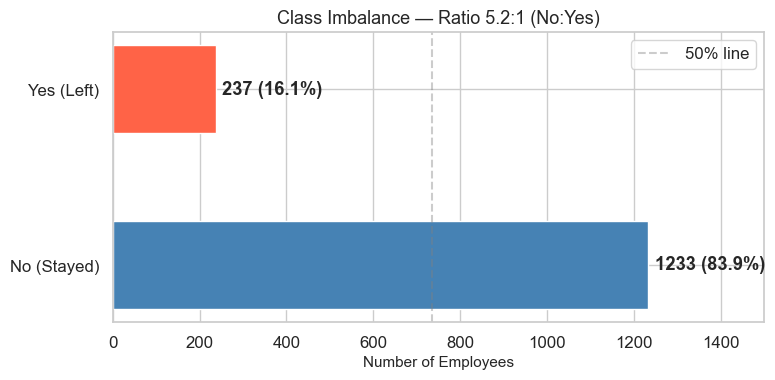

In [25]:
# Class imbalance
attrition_counts = df['Attrition'].value_counts()
imbalance_ratio = attrition_counts['No'] / attrition_counts['Yes']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(['No (Stayed)', 'Yes (Left)'],
               [attrition_counts['No'], attrition_counts['Yes']],
               color=['steelblue', 'tomato'], height=0.5)
for bar, count in zip(bars, [attrition_counts['No'], attrition_counts['Yes']]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f'{count} ({count / df.shape[0] * 100:.1f}%)', va='center', fontweight='bold')
ax.set_xlabel('Number of Employees')
ax.set_title(f'Class Imbalance — Ratio {imbalance_ratio:.1f}:1 (No:Yes)')
ax.set_xlim(0, 1500)
ax.axvline(x=df.shape[0] * 0.5, color='gray', linestyle='--', alpha=0.4, label='50% line')
ax.legend()
plt.tight_layout()
plt.show()

## 3. What drives people to leave

Each factor below is shown as an **attrition rate** — the share of employees in that group who left. The dashed line is the company-wide average (~16%); bars above it are higher-risk groups. They're ordered by how strong the signal is.

### 3.1 Overtime — the single strongest signal

Employees who work overtime leave at **~30%**, three times the **~10%** rate of those who don't.

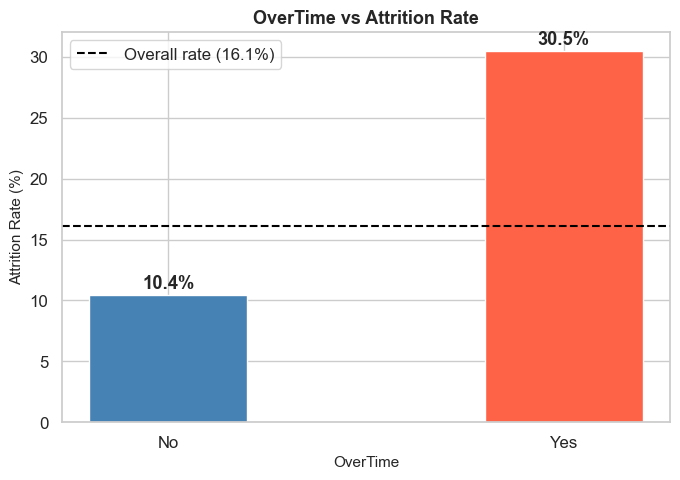

In [26]:
# OverTime vs attrition rate
ot_rate = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
ot_rate.columns = ['OverTime', 'AttritionRate']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(ot_rate['OverTime'], ot_rate['AttritionRate'],
              color=['steelblue', 'tomato'], width=0.4, edgecolor='white')
ax.axhline(y=overall_rate, color='black', linestyle='--', label=f'Overall rate ({overall_rate:.1f}%)')
for bar, val in zip(bars, ot_rate['AttritionRate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('OverTime vs Attrition Rate', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('OverTime')
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Business travel — more travel, more exits

Frequent travelers leave at **~25%**, versus just **~8%** for those who don't travel.

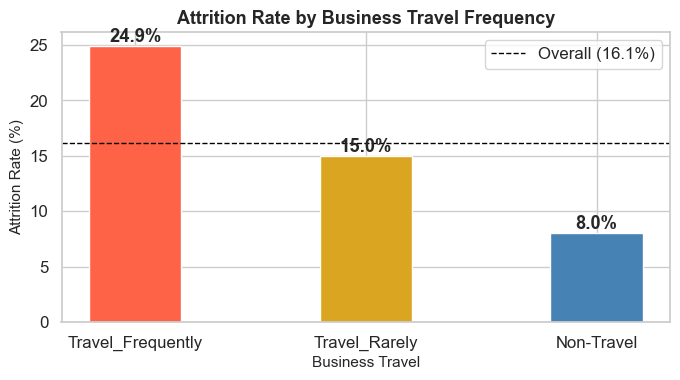

In [27]:
# BusinessTravel vs attrition rate
bt_rate = df.groupby('BusinessTravel')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bt_rate.index, bt_rate.values,
       color=['tomato', 'goldenrod', 'steelblue'], edgecolor='white', width=0.4)
ax.axhline(y=overall_rate, color='black', linestyle='--',
           linewidth=1, label=f'Overall ({overall_rate:.1f}%)')
for i, val in enumerate(bt_rate.values):
    ax.text(i, val + 0.4, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Attrition Rate by Business Travel Frequency', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Business Travel')
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Marital status — single employees are more mobile

Single employees leave at **~25%**, roughly double the **~12%** rate among married employees.

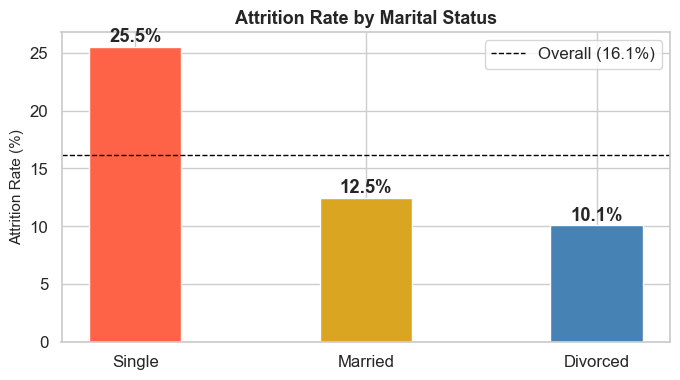

In [28]:
# MaritalStatus vs attrition rate
ms_rate = df.groupby('MaritalStatus')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ms_rate.index, ms_rate.values,
       color=['tomato', 'goldenrod', 'steelblue'], edgecolor='white', width=0.4)
ax.axhline(y=overall_rate, color='black', linestyle='--',
           linewidth=1, label=f'Overall ({overall_rate:.1f}%)')
for i, val in enumerate(ms_rate.values):
    ax.text(i, val + 0.4, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Attrition Rate by Marital Status', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 Job role & department — where the hotspots are

**Sales Representatives** and **Laboratory Technicians** have the highest attrition; managers and directors the lowest. At the department level, **Sales** runs hottest, followed by R&D.

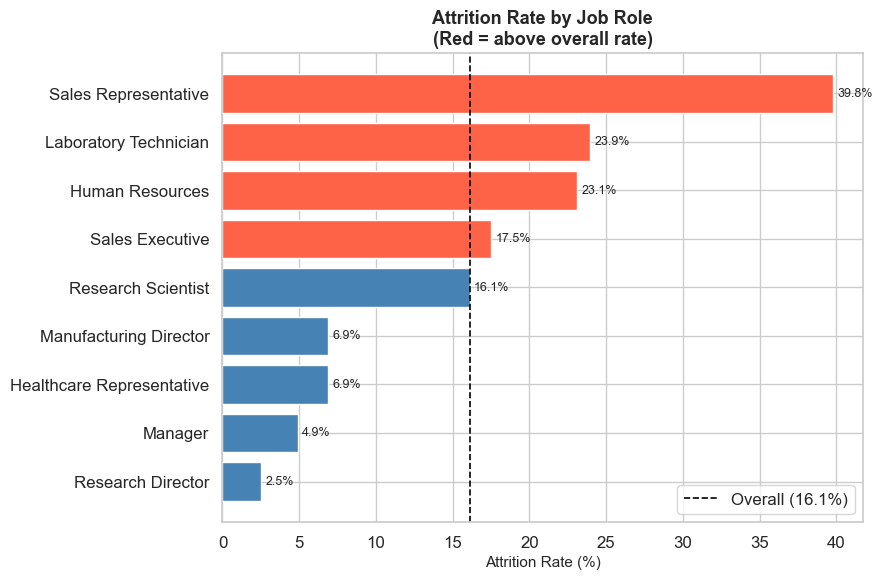

In [29]:
# JobRole vs attrition rate (horizontal bar)
jobrole_rate = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato' if v > overall_rate else 'steelblue' for v in jobrole_rate.values]
ax.barh(jobrole_rate.index, jobrole_rate.values, color=colors, edgecolor='white')
ax.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall ({overall_rate:.1f}%)')
for i, val in enumerate(jobrole_rate.values):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Job Role\n(Red = above overall rate)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

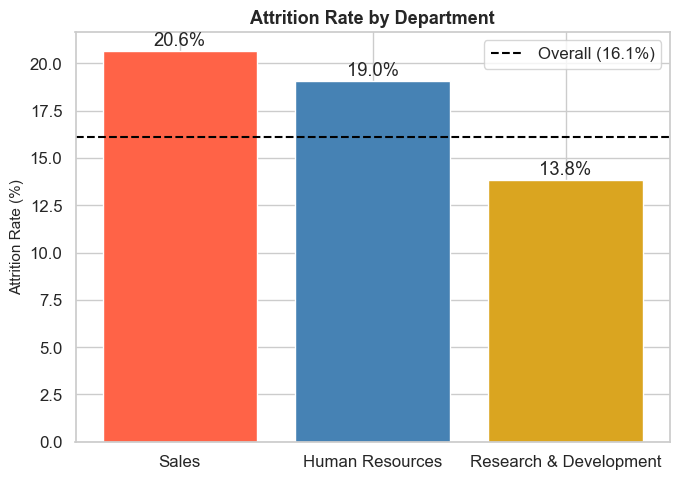

In [30]:
# Department vs attrition rate
dept_rate = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False).reset_index()
dept_rate.columns = ['Department', 'AttritionRate']

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(dept_rate['Department'], dept_rate['AttritionRate'],
       color=['tomato', 'steelblue', 'goldenrod'], edgecolor='white')
ax.axhline(y=overall_rate, color='black', linestyle='--',
           label=f'Overall ({overall_rate:.1f}%)')
ax.set_title('Attrition Rate by Department', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
for i, row in enumerate(dept_rate.itertuples()):
    ax.text(i, row.AttritionRate + 0.3, f'{row.AttritionRate:.1f}%', ha='center')
plt.tight_layout()
plt.show()

### 3.4a Job Role × Job Level — organisational hierarchy

Each role sits at a characteristic level in the hierarchy. This cross-tabulation shows what share of each role's headcount falls at each level — context for the pay benchmarking below.

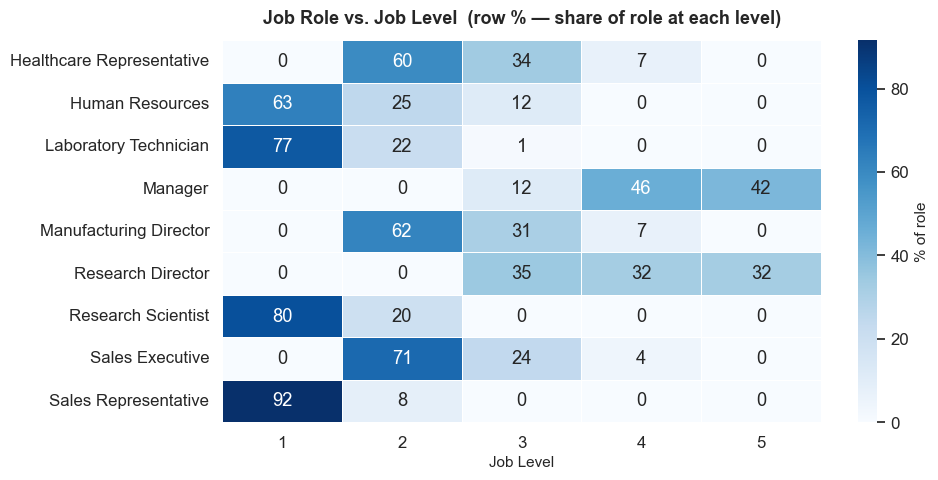

In [31]:
# Job role × job level heatmap (row-normalised %)
ct = pd.crosstab(df['JobRole'], df['JobLevel'], normalize='index').mul(100)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    ct, annot=True, fmt='.0f', cmap='Blues',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '% of role'},
    ax=ax
)
ax.set_title('Job Role vs. Job Level  (row % — share of role at each level)', fontweight='bold', pad=12)
ax.set_xlabel('Job Level')
ax.set_ylabel('')
ax.tick_params(axis='y', labelrotation=0)
plt.tight_layout()
plt.show()

### 3.4b Role composition within each department

R&D is dominated by **Research Scientists** and **Lab Technicians**; Sales by **Sales Executives** and **Sales Representatives**; HR is a small, single-role department. This headcount composition explains why the role-level attrition hotspots map so directly onto department-level risk.

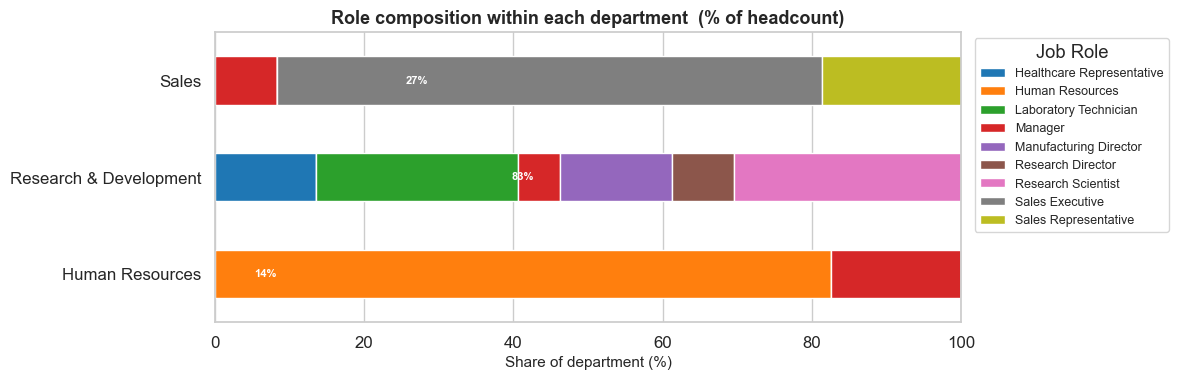

In [32]:
# Role composition within each department (100% stacked horizontal bar)
ct = df.groupby(['Department', 'JobRole']).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

colors = sns.color_palette("tab10", n_colors=ct_pct.shape[1])

fig, ax = plt.subplots(figsize=(12, 4))
ct_pct.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='white', width=0.5)

# Annotate segments >= 5% with their percentage
for bar_container, (_, row) in zip(ax.containers, ct_pct.iterrows()):
    left = 0
    for patch, val in zip(bar_container, row):
        if val >= 5:
            ax.text(left + val / 2, patch.get_y() + patch.get_height() / 2,
                    f'{val:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        left += val

ax.set_xlabel('Share of department (%)')
ax.set_ylabel('')
ax.set_title('Role composition within each department  (% of headcount)', fontweight='bold')
ax.set_xlim(0, 100)
ax.legend(title='Job Role', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### 3.5 Engagement & work-life balance — low scores roughly double the risk

Employees scoring **lowest** on job involvement, work-life balance, and satisfaction leave at ~30%+ — about double the company average. Engagement is one of the most actionable levers we have.

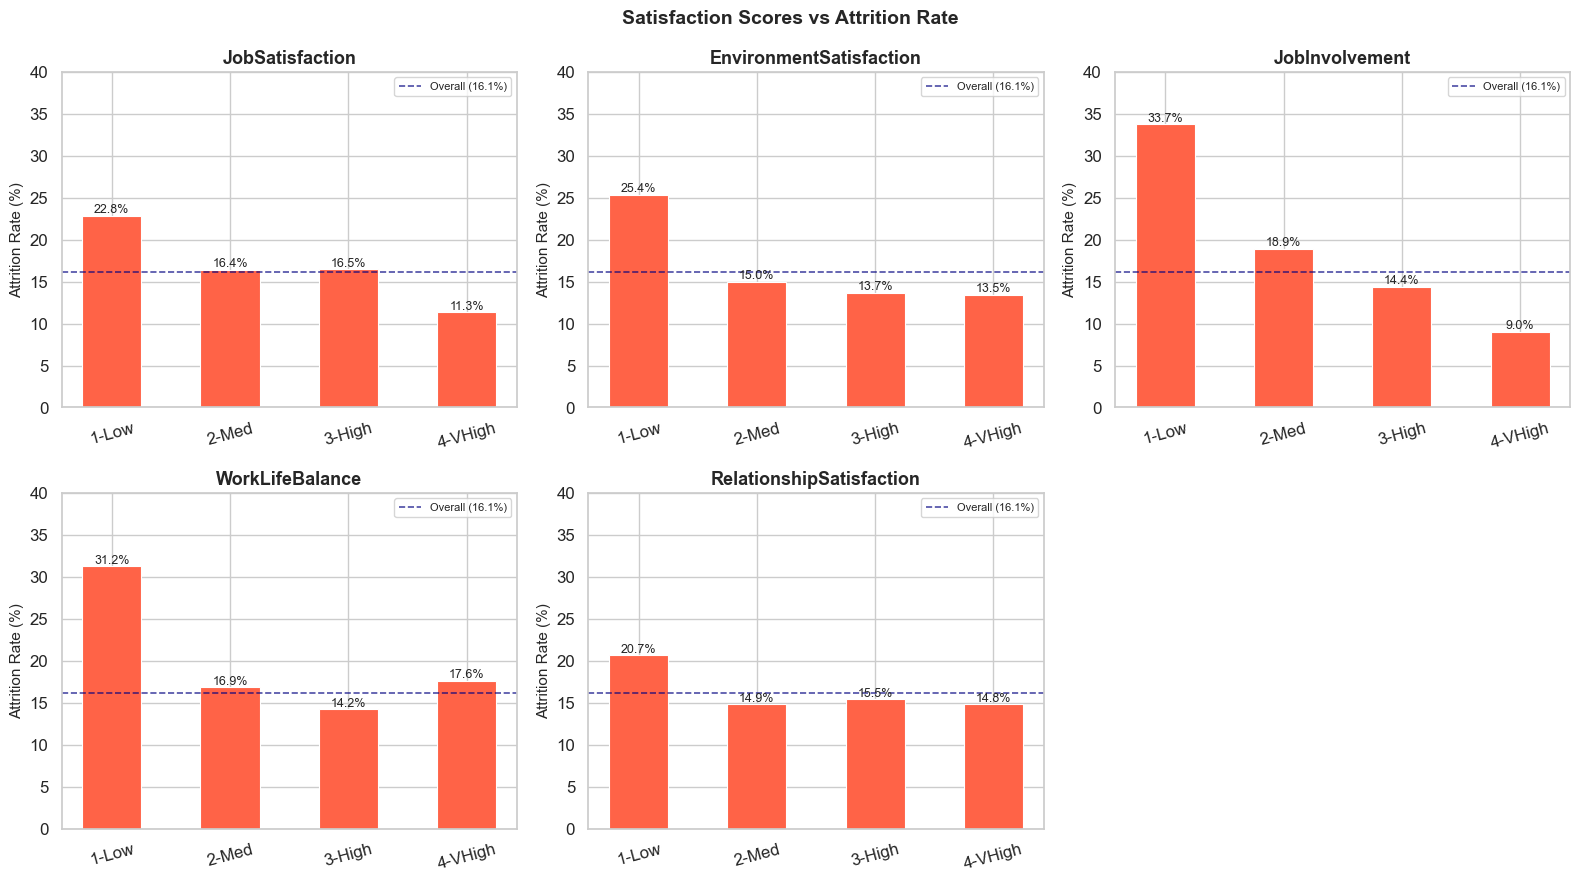

In [33]:
# Satisfaction & engagement scores vs attrition rate
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'JobInvolvement', 'WorkLifeBalance', 'RelationshipSatisfaction']
score_labels = {1: '1-Low', 2: '2-Med', 3: '3-High', 4: '4-VHigh'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(satisfaction_cols):
    rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').mean() * 100).reset_index()
    rate.columns = [col, 'AttritionRate']
    rate[col] = rate[col].map(score_labels)

    bars = axes[i].bar(rate[col], rate['AttritionRate'],
                       color='tomato', edgecolor='white', linewidth=0.8, width=0.5)
    axes[i].axhline(y=overall_rate, color='navy', linestyle='--', linewidth=1.2,
                    label=f'Overall ({overall_rate:.1f}%)', alpha=0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_ylim(0, 40)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, rate['AttritionRate']):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=9)
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)
plt.suptitle('Satisfaction Scores vs Attrition Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Pay — leavers earn less, especially within the same role

Employees who leave earn a **lower median income** than those who stay. The effect is sharpest inside the high-attrition roles (red below) — under-paying relative to peers in the same job is a flight risk.

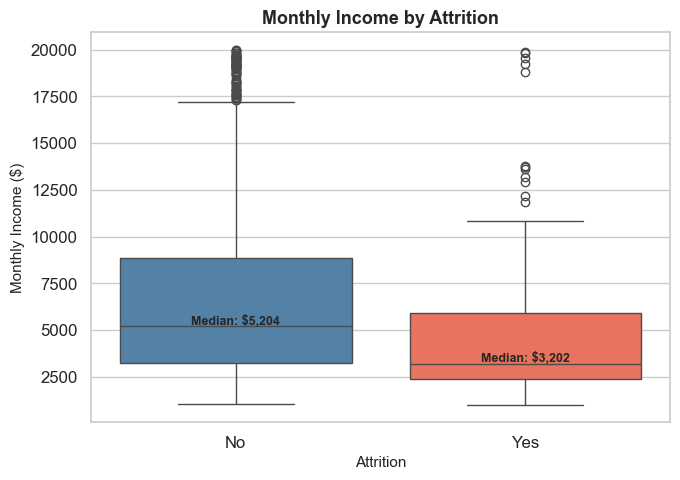

            count    mean     std     min     25%     50%     75%      max
Attrition                                                                 
No        1233.00 6833.00 4818.00 1051.00 3211.00 5204.00 8834.00 19999.00
Yes        237.00 4787.00 3640.00 1009.00 2373.00 3202.00 5916.00 19859.00


In [34]:
# Monthly income by attrition
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=ax,
            palette={'Yes': 'tomato', 'No': 'steelblue'}, order=['No', 'Yes'])
ax.set_title('Monthly Income by Attrition', fontweight='bold')
ax.set_ylabel('Monthly Income ($)')
for i, group in enumerate(['No', 'Yes']):
    median = df[df['Attrition'] == group]['MonthlyIncome'].median()
    ax.text(i, median + 100, f'Median: ${median:,.0f}',
            ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()
print(df.groupby('Attrition')['MonthlyIncome'].describe().round(0))

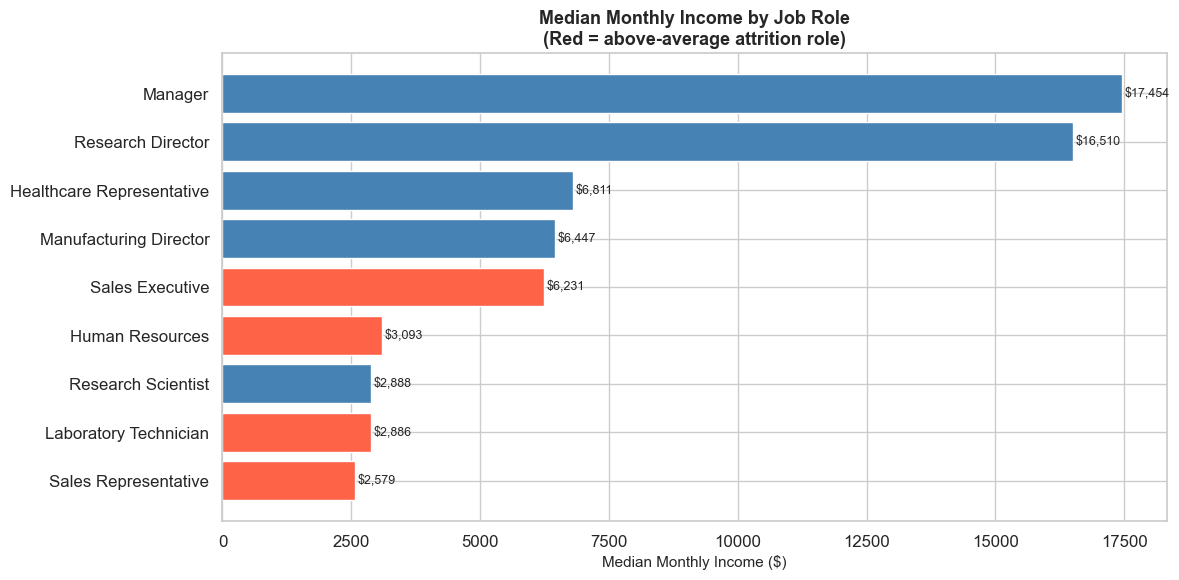

In [35]:
# Median monthly income by job role (red = above-average attrition role)
role_income = df.groupby('JobRole')['MonthlyIncome'].median().sort_values(ascending=True)
high_attrition_roles = jobrole_rate[jobrole_rate > overall_rate].index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
colors_role = ['tomato' if role in high_attrition_roles else 'steelblue'
               for role in role_income.index]
ax.barh(role_income.index, role_income.values, color=colors_role, edgecolor='white')
ax.set_xlabel('Median Monthly Income ($)')
ax.set_title('Median Monthly Income by Job Role\n(Red = above-average attrition role)', fontweight='bold')
for i, val in enumerate(role_income.values):
    ax.text(val + 50, i, f'${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 3.7 Tenure & promotions — the first two years are critical

Most attrition happens **early** — leavers have much shorter tenure. Promotion timing is non-linear: risk is high both for those **never promoted** and those **stuck 6+ years** without a promotion.

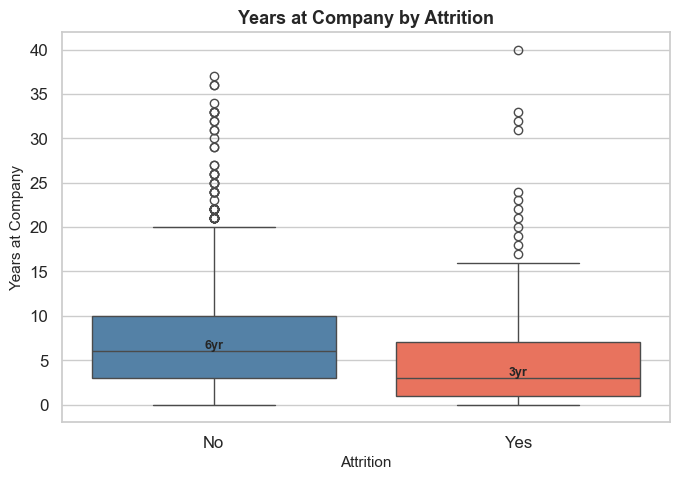

In [36]:
# Tenure — leavers have shorter time at the company
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', ax=ax,
            palette={'Yes': 'tomato', 'No': 'steelblue'}, order=['No', 'Yes'])
ax.set_title('Years at Company by Attrition', fontweight='bold')
ax.set_ylabel('Years at Company')
for j, group in enumerate(['No', 'Yes']):
    med = df[df['Attrition'] == group]['YearsAtCompany'].median()
    ax.text(j, med + 0.3, f'{med:.0f}yr', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

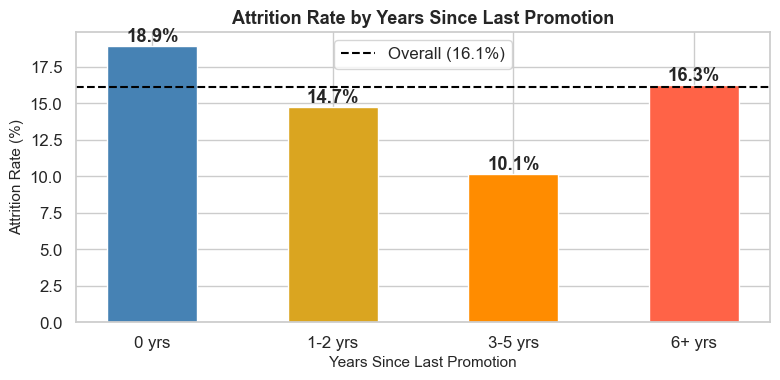

In [37]:
# Attrition rate by years since last promotion (binned)
df['PromoBucket'] = pd.cut(df['YearsSinceLastPromotion'],
                           bins=[-1, 0, 2, 5, 100],
                           labels=['0 yrs', '1-2 yrs', '3-5 yrs', '6+ yrs'])

promo_rate = df.groupby('PromoBucket', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(promo_rate.index.astype(str), promo_rate.values,
       color=['steelblue', 'goldenrod', 'darkorange', 'tomato'],
       edgecolor='white', width=0.5)
ax.axhline(y=overall_rate, color='black', linestyle='--',
           label=f'Overall ({overall_rate:.1f}%)')
ax.set_title('Attrition Rate by Years Since Last Promotion', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Years Since Last Promotion')
for i, val in enumerate(promo_rate.values):
    ax.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

df.drop(columns='PromoBucket', inplace=True)

## 4. How the factors relate (one caution)

The chart below ranks each factor by how strongly it moves with leaving (red = leaves more, blue = leaves less).

> **Caution for modeling:** several measures overlap heavily — e.g. years at company, total working years, years in role, and years with manager all rise together, and income tracks job level. We account for this when building the model (full correlation map in the appendix).

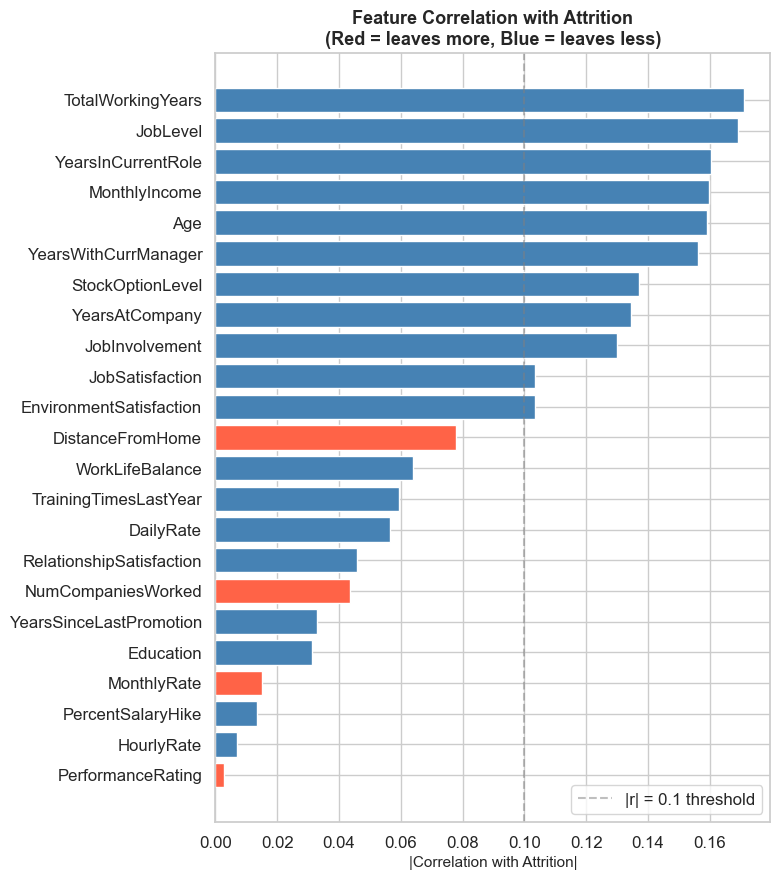

In [38]:
# How each factor correlates with leaving
df_corr = df.copy()
df_corr['Attrition_binary'] = (df_corr['Attrition'] == 'Yes').astype(int)
num_df = df_corr.select_dtypes(include=['int64', 'float64'])
corr_matrix = num_df.corr()

attrition_corr = corr_matrix['Attrition_binary'].drop('Attrition_binary')
attrition_corr_sorted = attrition_corr.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['tomato' if attrition_corr[col] > 0 else 'steelblue'
          for col in attrition_corr_sorted.index]
ax.barh(attrition_corr_sorted.index, attrition_corr_sorted.values,
        color=colors, edgecolor='white')
ax.set_xlabel('|Correlation with Attrition|')
ax.set_title('Feature Correlation with Attrition\n(Red = leaves more, Blue = leaves less)', fontweight='bold')
ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='|r| = 0.1 threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. What this means — retention levers

The drivers above point to four concrete, controllable actions:

| Lever | Who to target | Rationale |
|---|---|---|
| **Cap / monitor overtime** | Anyone consistently logging overtime | Strongest single driver — 30% vs 10% |
| **Review below-peer pay** | Employees paid below the median for their role & level | Leavers earn less within the same role |
| **Strengthen early-tenure onboarding** | Employees in their first 1–2 years | Most attrition happens early |
| **Enrich low-involvement roles & rebalance travel** | Low engagement / heavy-travel staff | Low engagement and frequent travel each roughly double risk |

Combined with travel load and marital/role context, these let HR focus retention spend on the employees most likely to leave — and most worth keeping.

## Appendix — technical detail

Denser, analyst-oriented views kept out of the main story: full descriptive statistics, the per-feature distributions, the complete correlation matrix, and the modeling implications.

In [39]:
# Full descriptive statistics
display(df.describe().T)
df.describe(include='object').T

,count,mean,std,min,25%,50%,75%,max
Age,1470.00,36.92,9.14,18.00,30.00,36.00,43.00,60.00
DailyRate,1470.00,802.49,403.51,102.00,465.00,802.00,1157.00,1499.00
DistanceFromHome,1470.00,9.19,8.11,1.00,2.00,7.00,14.00,29.00
Education,1470.00,2.91,1.02,1.00,2.00,3.00,4.00,5.00
EnvironmentSatisfaction,1470.00,2.72,1.09,1.00,2.00,3.00,4.00,4.00
HourlyRate,1470.00,65.89,20.33,30.00,48.00,66.00,83.75,100.00
JobInvolvement,1470.00,2.73,0.71,1.00,2.00,3.00,3.00,4.00
JobLevel,1470.00,2.06,1.11,1.00,1.00,2.00,3.00,5.00
JobSatisfaction,1470.00,2.73,1.10,1.00,2.00,3.00,4.00,4.00
MonthlyIncome,1470.00,6502.93,4707.96,1009.00,2911.00,4919.00,8379.00,19999.00


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
OverTime,1470,2,No,1054


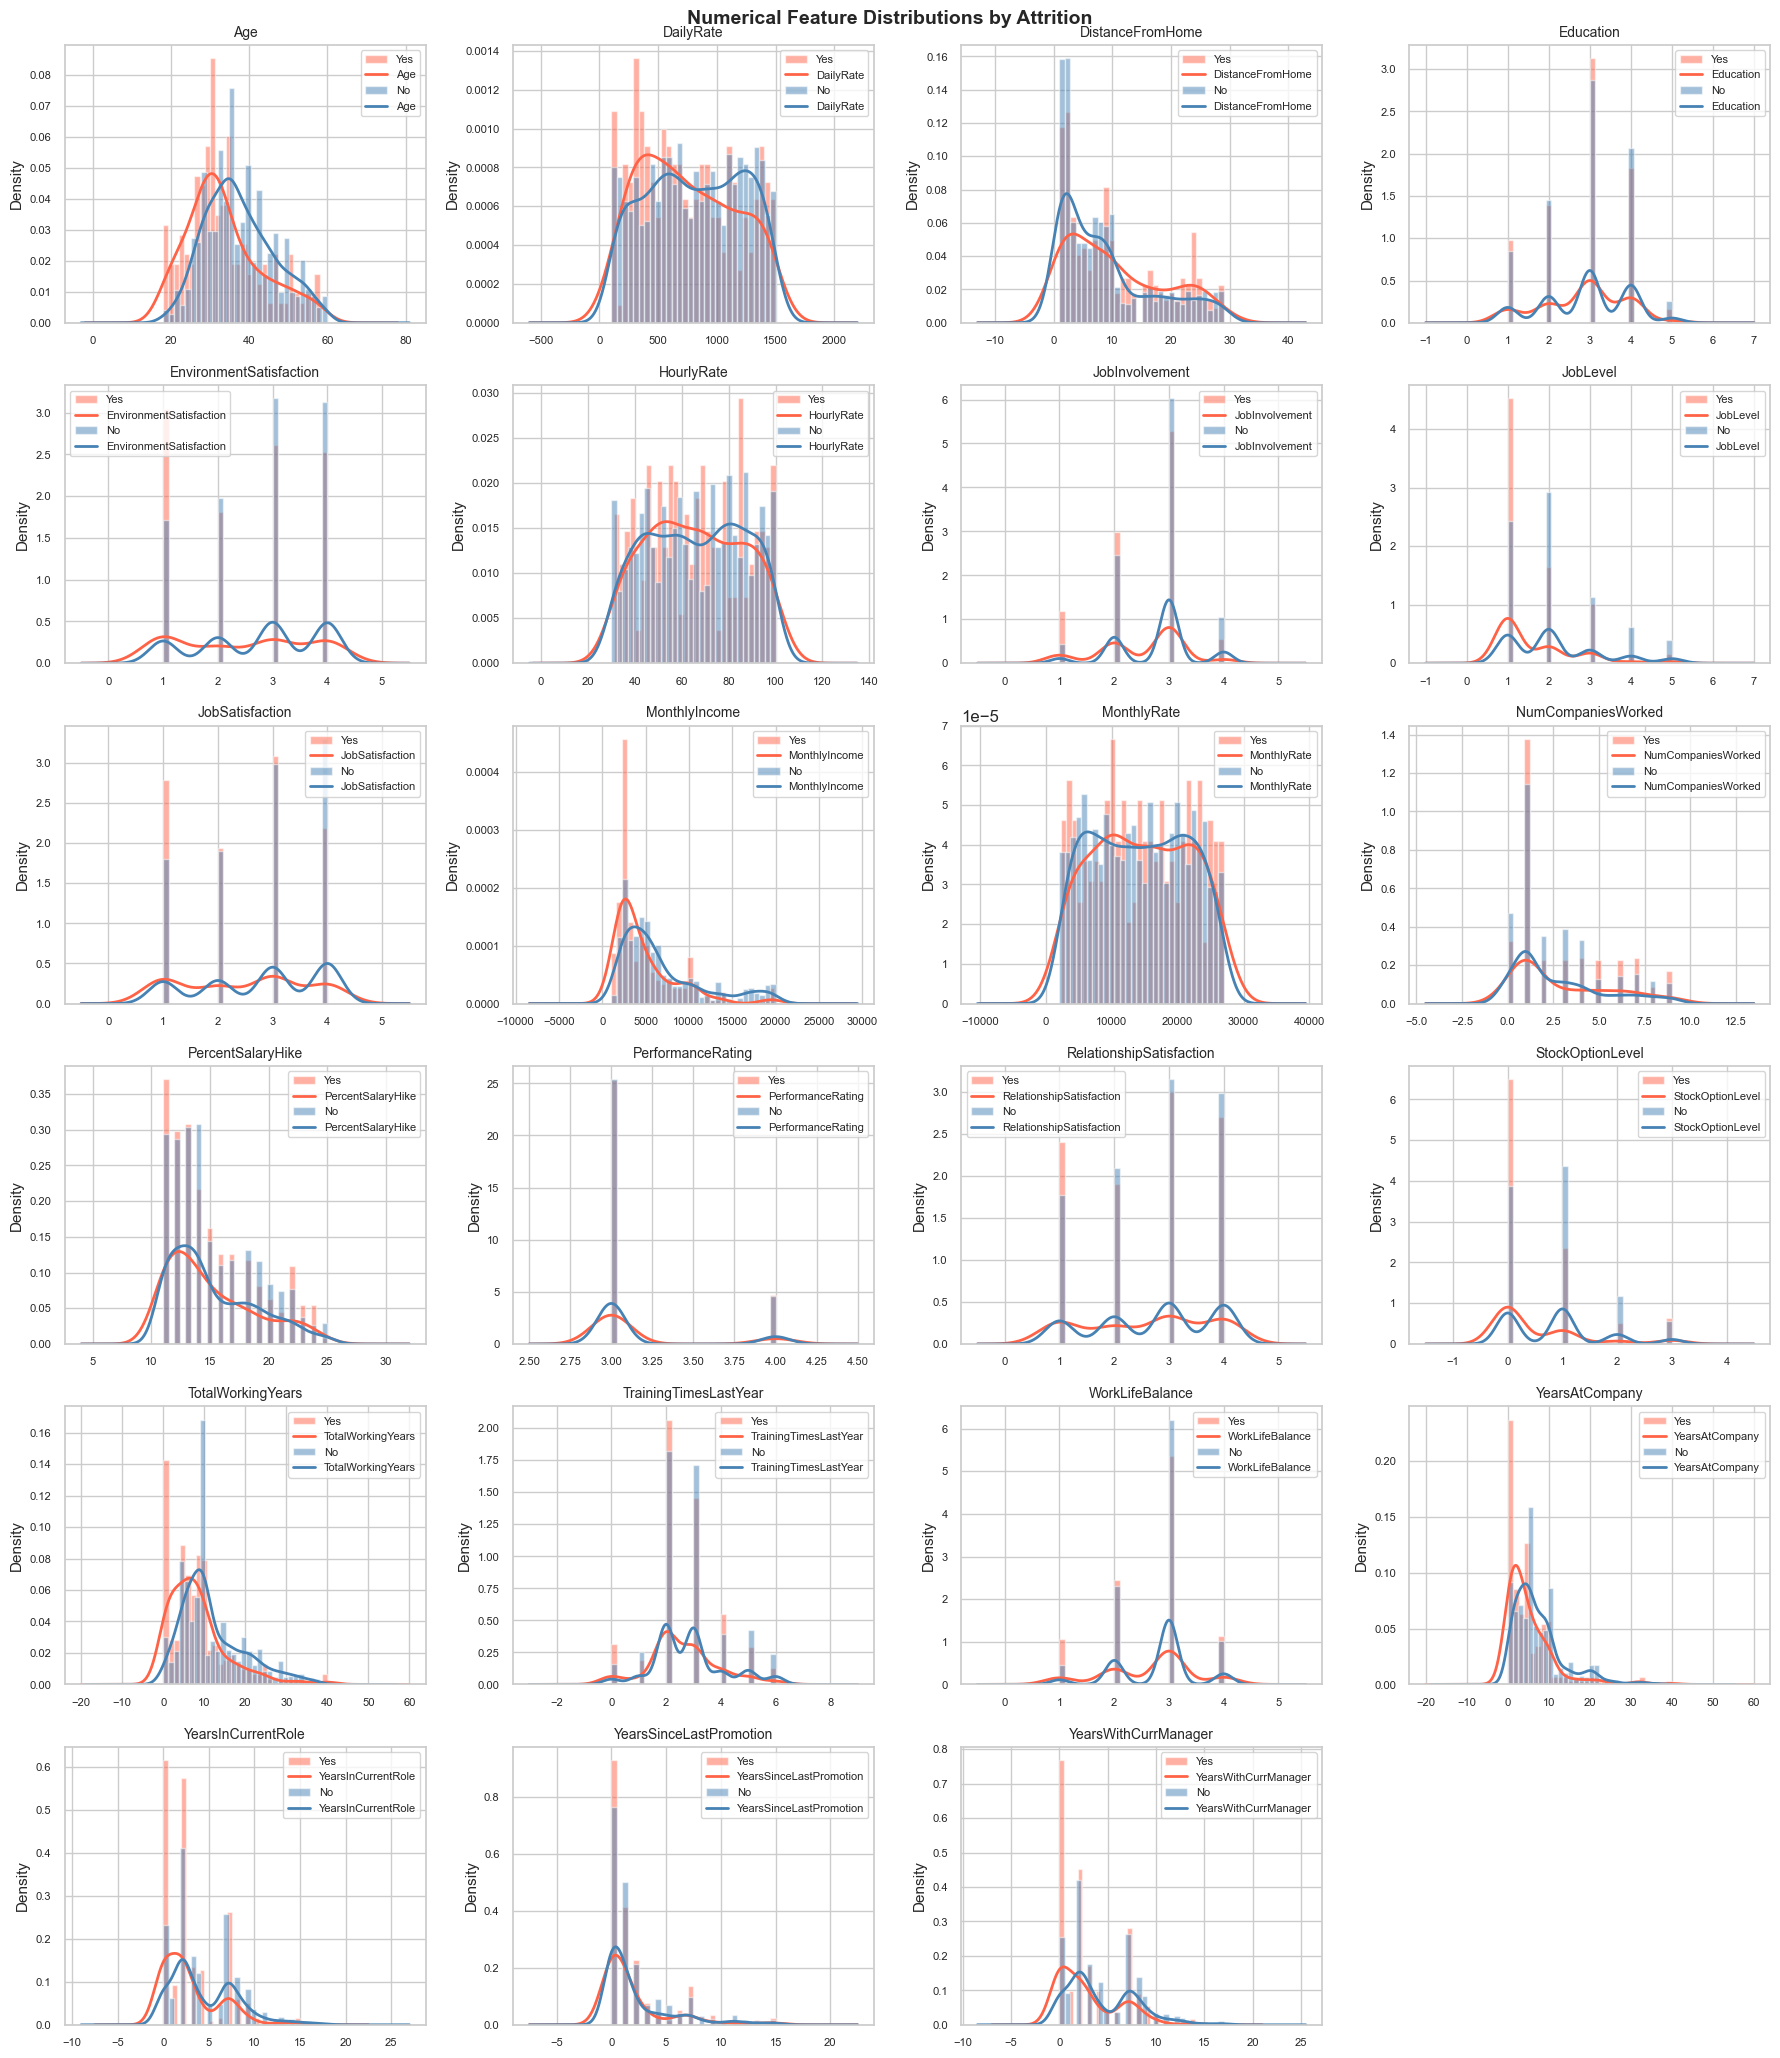

In [40]:
# Numerical feature distributions by attrition (per-feature KDE / histogram)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()
palette = {'Yes': 'tomato', 'No': 'steelblue'}

for i, col in enumerate(numerical_cols):
    for attrition_val, color in palette.items():
        subset = df[df['Attrition'] == attrition_val][col]
        axes[i].hist(subset, bins=30, alpha=0.5, color=color,
                     label=attrition_val, density=True)
        subset.plot.kde(ax=axes[i], color=color, linewidth=2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

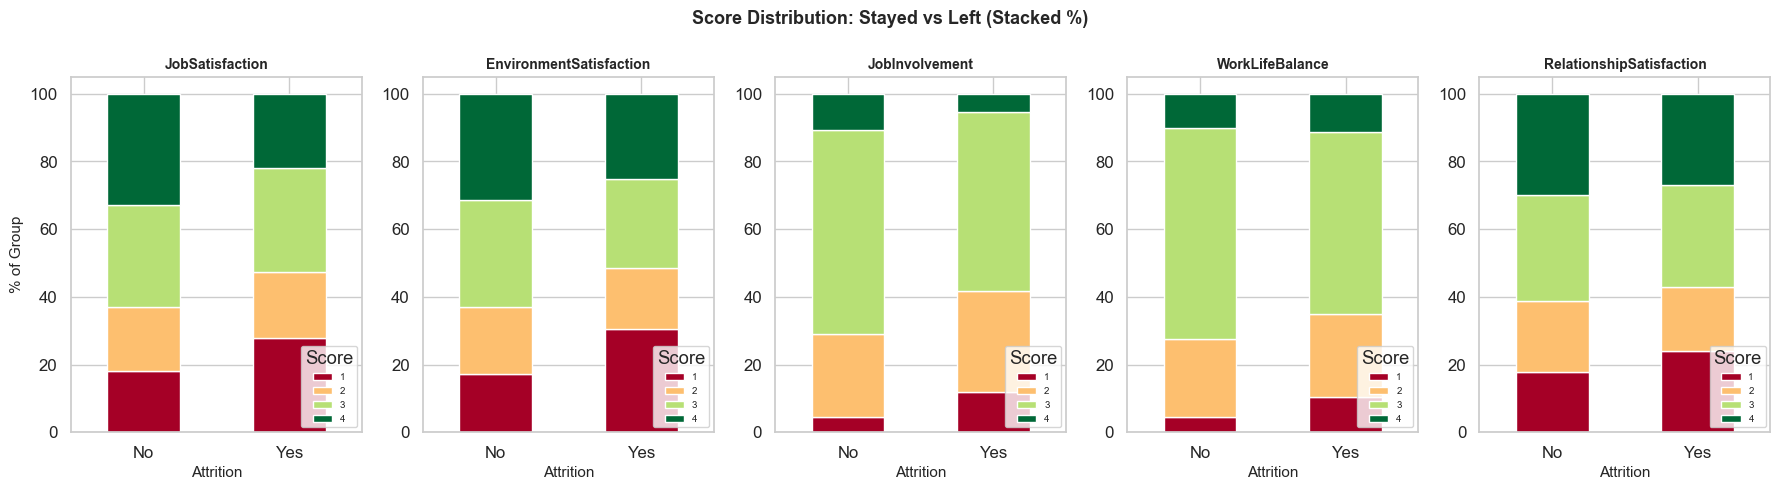

In [41]:
# Satisfaction score distribution: stayed vs left (stacked %)
fig, axes = plt.subplots(1, len(satisfaction_cols), figsize=(18, 5))

for i, col in enumerate(satisfaction_cols):
    cross = pd.crosstab(df['Attrition'], df[col], normalize='index') * 100
    cross.plot(kind='bar', stacked=True, ax=axes[i],
               colormap='RdYlGn', edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Attrition')
    axes[i].set_ylabel('% of Group' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Score', fontsize=7, loc='lower right')

plt.suptitle('Score Distribution: Stayed vs Left (Stacked %)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

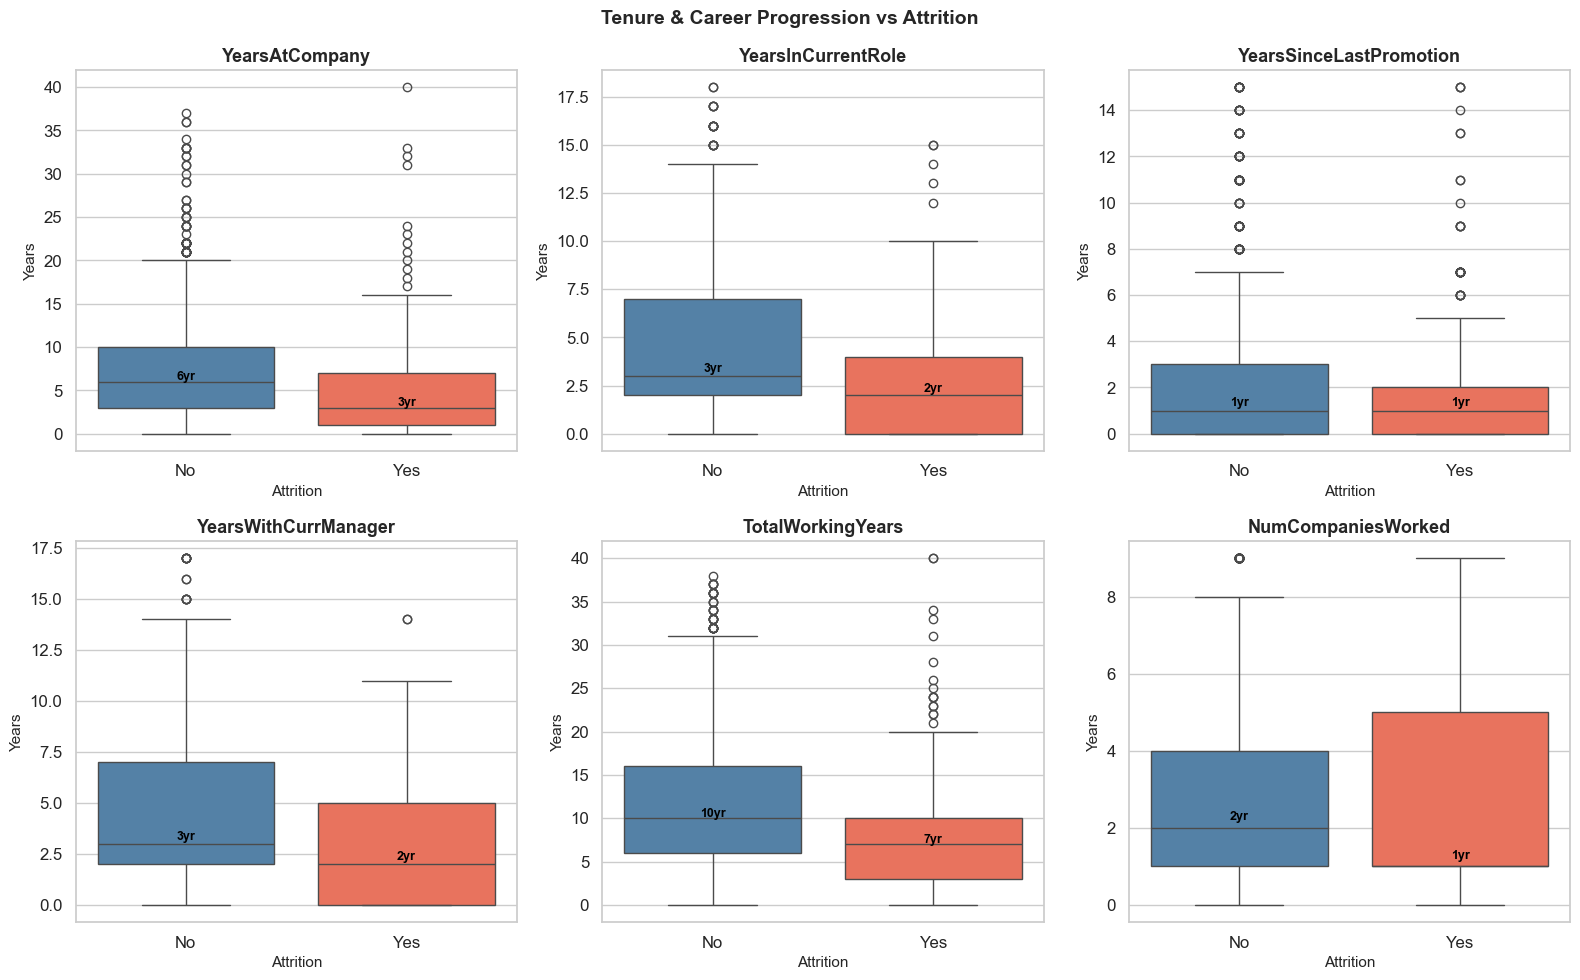

In [42]:
# Full tenure & career progression panel
tenure_cols = ['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
               'YearsWithCurrManager', 'TotalWorkingYears', 'NumCompaniesWorked']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(tenure_cols):
    sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i],
                palette={'Yes': 'tomato', 'No': 'steelblue'}, order=['No', 'Yes'])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Attrition')
    axes[i].set_ylabel('Years')
    for j, group in enumerate(['No', 'Yes']):
        med = df[df['Attrition'] == group][col].median()
        axes[i].text(j, med + 0.2, f'{med:.0f}yr', ha='center', fontsize=9,
                     color='black', fontweight='bold')

plt.suptitle('Tenure & Career Progression vs Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

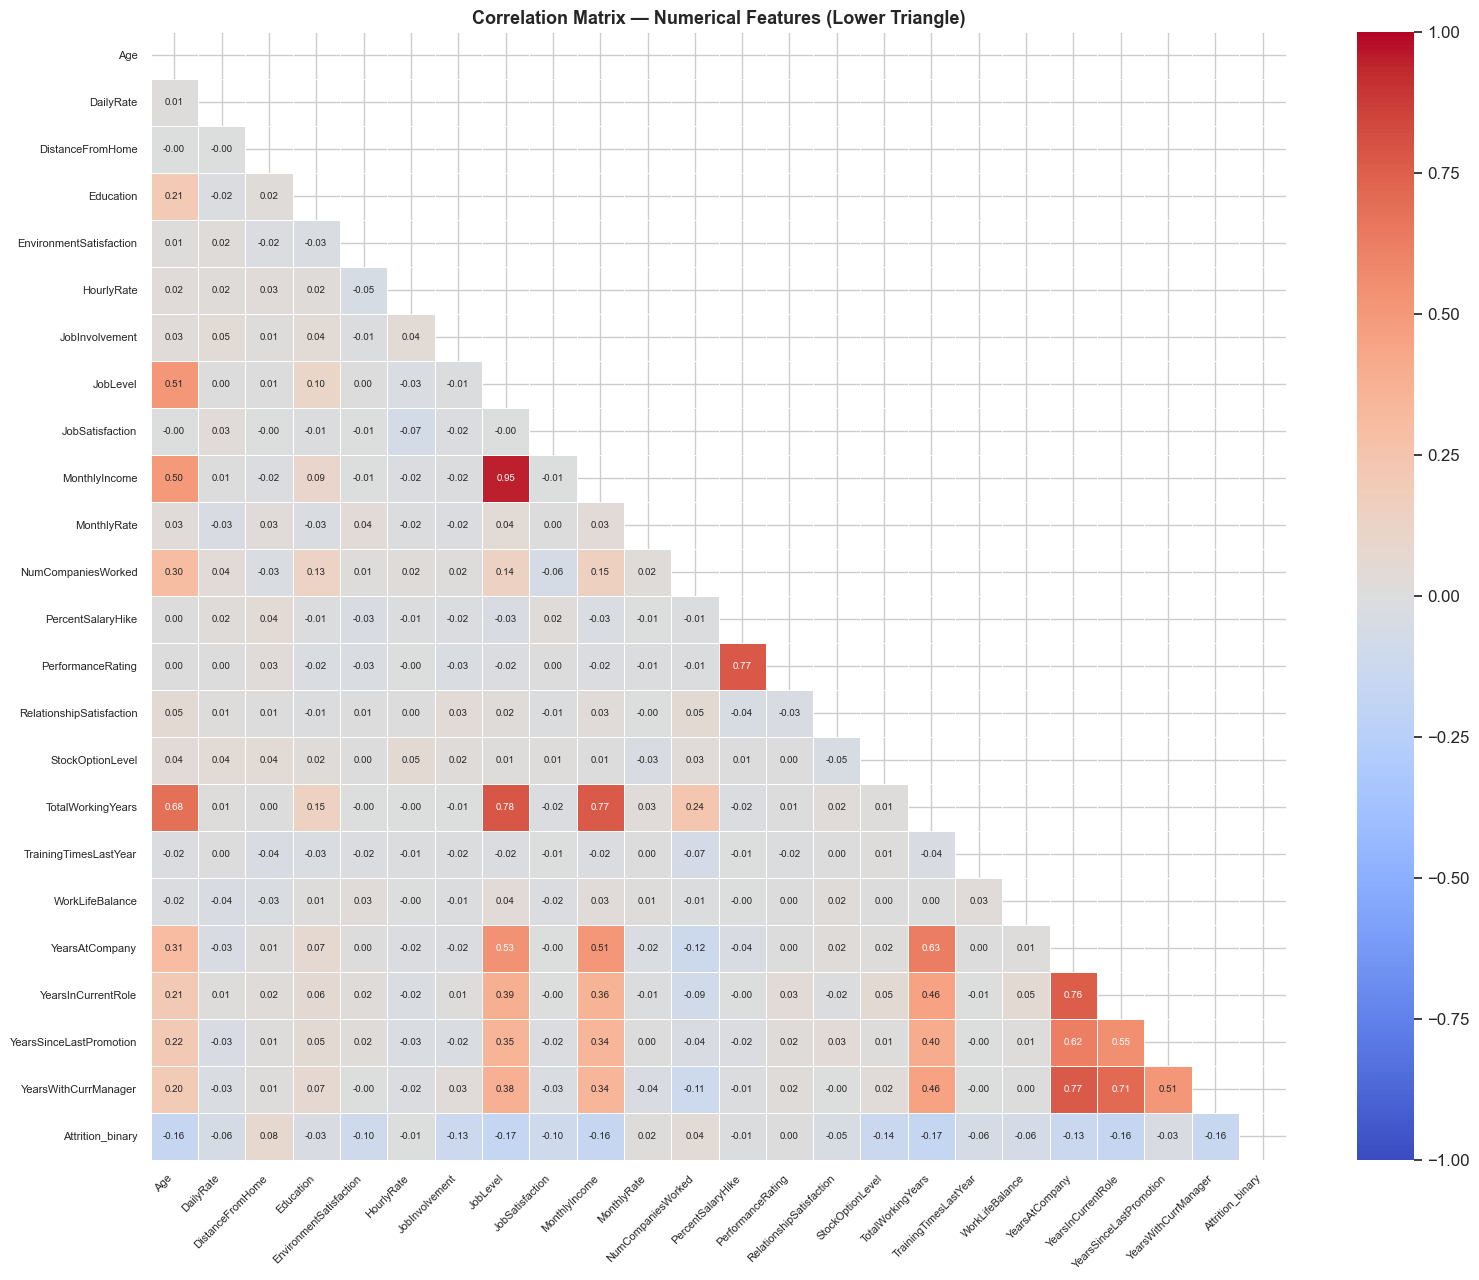

In [43]:
# Full correlation matrix (lower triangle)
df_corr_full = df.copy()
df_corr_full['Attrition_binary'] = (df_corr_full['Attrition'] == 'Yes').astype(int)
df_corr_full.drop(columns=['Attrition'], inplace=True)
num_df_full = df_corr_full.select_dtypes(include=['int64', 'float64'])
corr_matrix_full = num_df_full.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix_full, dtype=bool))
sns.heatmap(corr_matrix_full, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features (Lower Triangle)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Modeling implications

- **Don't use accuracy** — ~84% is achievable by always predicting "No". Priority metrics: **Recall (Yes)**, **F1 (Yes)**, **ROC-AUC**, **PR-AUC**.
- **Class imbalance handling:** SMOTE, `class_weight='balanced'`, or threshold tuning.
- **High-signal features:** `OverTime`, `MonthlyIncome`, `JobRole`, `JobInvolvement`, `MaritalStatus`, `YearsAtCompany`, `WorkLifeBalance`, `BusinessTravel`.
- **Multicollinearity to watch:** tenure cluster (`YearsAtCompany` / `TotalWorkingYears` / `YearsInCurrentRole` / `YearsWithCurrManager`) and `MonthlyIncome` ↔ `JobLevel`.